# Simple Linear Regression from scratch
### Implementation using Ordinary Least Squares (OLS) and Numpy Vectorization

**Author:** Kush Pal  
**Date:** 13 May 2026  
**Objective:** To implement a simple linear regression engine from first principles, utilizing the mathematical foundations found in *An Introduction to Statistical Learning* (ISLP). This project avoids high-level machine learning libraries like scikit-learn to demonstrate a deep understanding of the underlying statistics and optimization techniques.

## 1. The Mathematical Model

The simple linear regression model takes one single predictor variable only to predict the Response.
$$ Y \approx \beta_0 + \beta_1X \tag{1} $$
where  
* Y is the Response
* X is the Predictor Variable
* $\beta_0,\beta_1$ are the parameters or model coefficients
 To fit the model we need to estimate the slope $\beta_1$ and intercept $\beta_0$ from the training data in order to predict the response for future data.
Predictions will be given by the following equation 
$$\hat{y} = \hat{\beta_0} + \hat{\beta_1}x \tag{2}$$
* $\hat{y}$ is the prediction done when X = x
* $\hat{\beta_0} ,\hat{\beta_1} $ are the parameters value calculated on the training data
* x is the predictor variable value
### Residual Sum of Squares (RSS)


### Definition
While a line is fitted on a data. The Sum of Squared differences between the line and data points is called a Residual Sum of Squares. The difference itself is called a residual.

### Estimating Parameters
In order to estimate Parameters from training data we fit a straight line to the data using the least squares method .  
LEAST SQUARES METHOD works by calculating the RSS of the data and minimizing it . We take the parameters for which the RSS value is the least.


### RSS equation
$$RSS = \sum_{i=1}^{n} (y_i - \hat{y_i})^2 \tag{3}$$ <center>OR</center> $$RSS = \sum_{i=1}^{n} (y_i - (\hat{\beta_0} + \hat{\beta_1}x) )^2 \tag{4}$$

### The Closed Form Solution  
To minimize RSS we use Partial Derivatives on the RSS equation with respect to $\beta_0$ and $\beta_1$ and equating the partial derivatives to 0 in order to find the $\beta_0$ and $\beta_1$ . 
$$\frac{\partial (RSS)}{\partial (\beta_0)} = 0 \tag{5}$$ $$\frac{\partial (RSS)}{\partial (\beta_1)} = 0 \tag{6}$$
After solving the above equation we get the $\hat{\beta_0}$ and $\hat{\beta_1}$ for the model
$$ \hat{\beta_1} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2} \tag{7}$$
$$ \hat{\beta_0} = \bar{y} - \hat{\beta_1}\bar{x} \tag{8}$$
where  
* $\bar{y}$ is just the mean of y calculated using $\frac{1}{n}\sum_{i=1}^{n}y_i$
* $\bar{x}$ is just the mean of x calculated using $\frac{1}{n}\sum_{i=1}^{n}x_i$
After obtaining the parameters for least squares. The model is ready for predicting $\hat{y}$ using the equation number 2 given X = x.

In [1]:
import numpy as np

# Making the simple linear regression function from numpy vectorisation.

def Simple_Linear_Regression(X,Y):
    
    # Calculates mean for X and Y.
    a= np.mean(X)
    b= np.mean(Y)

    # Calculates terms for the slope using vectorisation to obtain O(N) efficiency instead of loop
    num = np.sum((X - a)*(Y - b))
    den = np.sum((X - a)**2)

    # Above can also be achieved throught the following loop as well
    # num = 0
    # den = 0

    # # for i in range(len(X)):
    # #     num = num + (X[i] - a)*(Y[i] - b)
    # #     den = den + (X[i] - a) ** 2

    # Final parameters
    slope = num/den
    intercept = b - slope*a

    return slope , intercept

print('Engine Created Successfully')

Engine Created Successfully


## 2. Generating Synthetic Data and Estimating Coefficients

In [2]:
# Creating Synthetic data for testing 

# Setting a seed for reproducibility 
np.random.seed(42)

# Synthetic Population Parameters
true_slope  = 4.1
true_intercept = 5.3

# Generate Synthetic Data
X = 10*np.random.rand(100)
noise = np.random.randn(100)*2 #Gaussian Noise
Y = true_slope * X + true_intercept + noise

print(f"Generated 100 data points with the true slope = {true_slope} and true intercept = {true_intercept}.")


Generated 100 data points with the true slope = 4.1 and true intercept = 5.3.


In [3]:
# Testing the Engine 

# Slope and Intercept calculated on the basis of synthetic data.
m,c = Simple_Linear_Regression(X,Y)

print('-'*30)
print('RESULTS')
print('-'*30)
print(f"True Slope: {true_slope} | Model slope: {m:.4f}")
print(f"True Intercept: {true_intercept} | Model Intercept: {c:.4f}")



------------------------------
RESULTS
------------------------------
True Slope: 4.1 | Model slope: 4.0080
True Intercept: 5.3 | Model Intercept: 5.7302


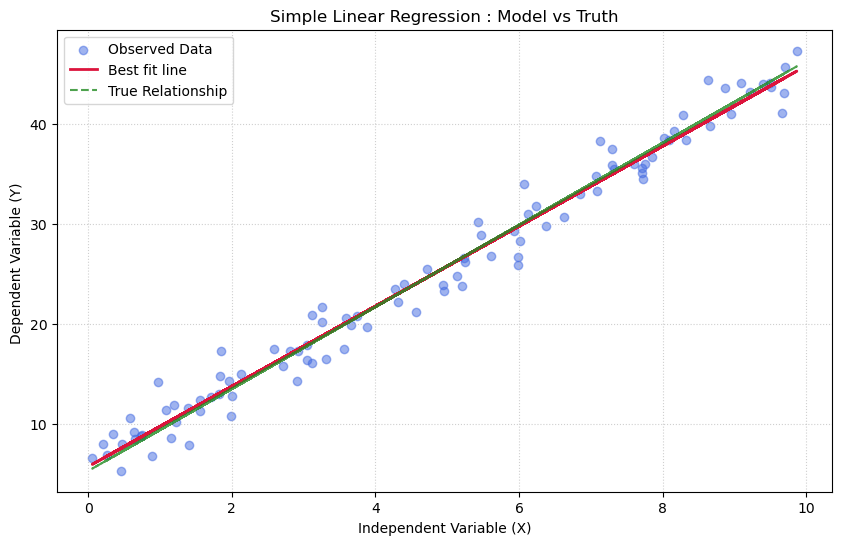

In [4]:
# Visualizing the Model

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Plotting Raw Data
plt.scatter(X,Y,label = 'Observed Data',color = 'royalblue',alpha = 0.5)

# Plotting Model Predictions
predicted_y = X*m + c
plt.plot(X,predicted_y,label= f'Best fit line',color = 'crimson',linewidth = 2)

# Plotting Population Truth
true_y = true_slope*X + true_intercept
plt.plot(X,true_y,color = 'forestgreen',label = 'True Relationship',alpha = 0.8,linestyle = '--')

plt.title('Simple Linear Regression : Model vs Truth')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (Y) ')
plt.legend()
plt.grid(True,linestyle = ':',alpha = 0.6)
plt.show()

## 3. Assessing Accuracy of Estimated Coefficients  
At this point we have estimated the slope($\hat{\beta_1}$) and intercept($\hat{\beta_0}$) using the synthetic data whose true intercept and slope are known. But in real world scenarios, we only have one dataset and cannot know the true parameters. In this section, we will run a Monte Carlo simulation to demonstrate a fundamental statistical property: the OLS estimator is unbiased. By averaging the estimates from 1000 different simulated datasets, we can prove that the math naturally centers around the true population parameters.    
    
If we estimate the data on different Datasets with same true parameters that we defined earlier we will get different estimates of the coefficients. But if we take those different estimates and find their average, then it is observed that this average of estimates will get closer to the true values of the parameters. The more estimates we have, the more accurate their average will be compared to the true parameters.  

We can easily observe this above phenomenon using the following code.


In [5]:
# Generating 1000 sets of Synthetic Data using true_slope and true_intercept
np.random.seed(27)

m_list = []
c_list = []

for i in range (1000):

    # Generating Dataset
    noise_sim = np.random.randn(100)*2 #Gaussian Noise
    Y_sim = true_slope * X + true_intercept + noise_sim

    # Finding estimates for the Data Generated
    m_est,c_est = Simple_Linear_Regression(X,Y_sim)
    m_list.append(m_est) 
    c_list.append(c_est)  

m_arr = np.array(m_list) # array of estimated slopes
c_arr = np.array(c_list) # array of estimated intercepts

print(f"True Slope : {true_slope} | Single estimated Slope {m:.4f} | Average of estimated Slopes : {np.mean(m_arr):.4f}")
print(f"True Intercept : {true_intercept} | Single estimated Intercept {c:.4f} |  Average of estimated Intercepts : {np.mean(c_arr):.4f}")


True Slope : 4.1 | Single estimated Slope 4.0080 | Average of estimated Slopes : 4.0997
True Intercept : 5.3 | Single estimated Intercept 5.7302 |  Average of estimated Intercepts : 5.2966


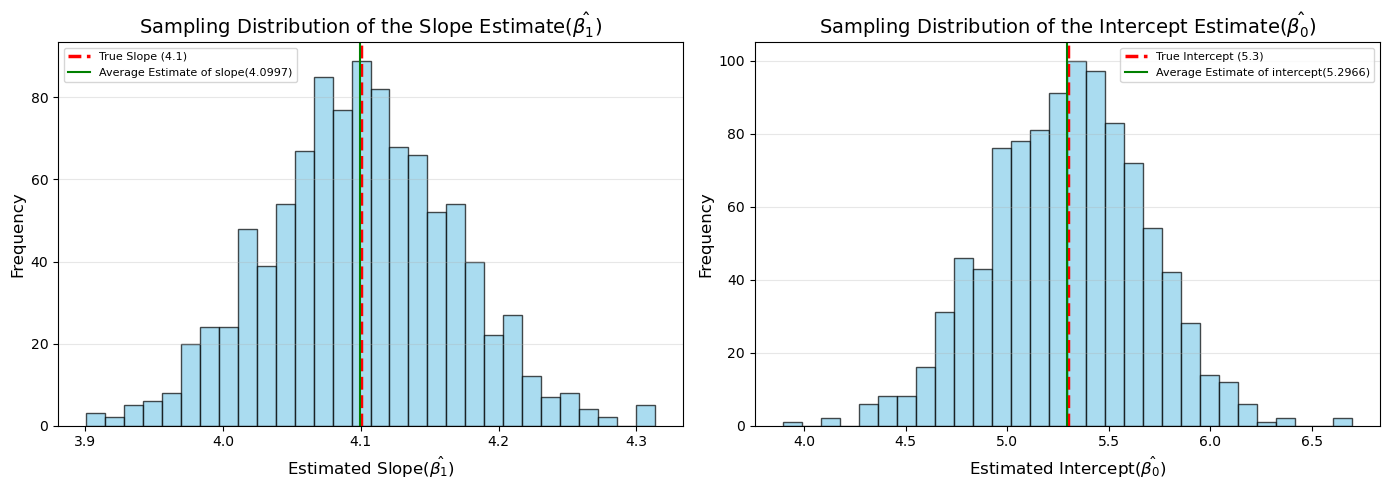

In [6]:
# Creates a figure of 1 row and 2 columns of subplots
fig,axs=plt.subplots(1,2,figsize=(14,5))

# Plotting histogram of Estimated Slopes
axs[0].hist(m_arr,bins=30,color='skyblue',alpha=0.7,edgecolor='black')

# Plotting True Slope Line
axs[0].axvline(x=true_slope,color='red',linestyle='--',linewidth=2.5,label=f"True Slope ({true_slope})")

# Plotting Average of estimated Slopes
axs[0].axvline(x=np.mean(m_arr),color='green',linestyle='-',linewidth=1.5,label=f"Average Estimate of slope({np.mean(m_arr):.4f})")

# Customizations for Slope plots
axs[0].set_title('Sampling Distribution of the Slope Estimate($\hat{\\beta_1}$)',fontsize=14)
axs[0].set_xlabel('Estimated Slope($\hat{\\beta_1}$)',fontsize=12)
axs[0].set_ylabel('Frequency',fontsize=12)
axs[0].legend(loc='upper left',fontsize=8)
axs[0].grid(axis='y',alpha=0.3)

# Plotting histogram of Estimated Intercepts
axs[1].hist(c_arr,bins=30,color='skyblue',alpha=0.7,edgecolor='black')

# Plotting True Intercept Line
axs[1].axvline(x=true_intercept,color='red',linestyle='--',linewidth=2.5,label=f"True Intercept ({true_intercept})")

# Plotting Average of estimated Intercepts
axs[1].axvline(x=np.mean(c_arr),color='green',linestyle='-',linewidth=1.5,label=f"Average Estimate of intercept({np.mean(c_arr):.4f})")

# Customizations for Intercept plot
axs[1].set_title('Sampling Distribution of the Intercept Estimate($\hat{\\beta_0}$)',fontsize=14)
axs[1].set_xlabel('Estimated Intercept($\hat{\\beta_0}$)',fontsize=12)
axs[1].set_ylabel('Frequency',fontsize=12)
axs[1].legend(loc='upper right',fontsize=8)
axs[1].grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

## 4. The Standard Error(SE)  

As we have already seen that increasing the number of datasets and averaging the estimates of their coefficients give us an accurate value of these coefficients. But in real world scenarios we will neither get the true parameters nor 1000 datasets for it. So we use **Standard Error** to deduce how well our estimated coefficients would represent the true parameters.  

The **Standard Error** measures the average expected amount that our single coefficient estimate ($\hat{\beta_0},\hat{\beta_1}$) will deviate from the actual unknown population parameter ($\beta_0 , \beta_1$). It represents the 'spread' or uncertainty of our estimate. Meaning it is standard deviation of the sampling distribution of our estimate. Rather than running a computationally expensive Monte Carlo simulation to find this spread. We can calculate it from a single dataset using the variance of the error terms ($\sigma^2$) and the spread of our predictor variable (X)

To find the SE of our estimates we find the variance of our estimates ($Var(\hat{\beta_1}),Var(\hat{\beta_0})$)

$$Var(\hat{\beta_0}) = SE(\hat{\beta_0})^2 = \sigma^2\left[\frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}\right]\tag{9}$$
$$Var(\hat{\beta_1}) = SE(\hat{\beta_1})^2 = \frac{\sigma^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}\tag{10}$$

where $Var(\epsilon) = \sigma^2$

The above formulas are obtained by applying variance on the slope and intercept formulas. These formulas are only valid under the following assumptions :  

* The errors ($\epsilon_i$) for each observation have common Variance $\sigma^2$.
* The error terms are uncorrelated.  

Although, the true value of $\sigma^2$ is not known in nature. But can be estimated from the data. The estimate of $\sigma$ is known as **Residual Standard Error(RSE)**.

$$RSE = \sqrt{\frac{RSS}{n-2}}\tag{11}$$
where, RSS is the Residual Sum of Errors  

In practice we use $RSE^2$ to find $\sigma^2$. This $RSE^2$ is known as the **Mean Squared Error(MSE)** adjusted for the degrees of freedom.  




In [7]:
# The Empirical Standard Error (using the 1000 simulated datasets)
emp_se_slope = np.std(m_arr)
emp_se_intercept = np.std(c_arr)

# Finding RSS,RSE, for Standar Error calculations
n = len(X)
rss = np.sum((Y - predicted_y)**2)
rse = np.sqrt(rss/(n-2))

# Calculating the Standard error using the formulas 9,10,11 on a single dataset
for_se_slope = rse/(np.sqrt(np.sum((X - np.mean(X))**2))) # Standard Error for slope
for_se_intercept = rse*np.sqrt((1/n) + (np.mean(X)**2/np.sum(((X - np.mean(X))**2))))

print('-'*50)
print('STANDARD ERROR (SE) COMPARISON')
print('-'*50)
print(f"Empirical SE of Slope:      {emp_se_slope:.4f}")
print(f"Theoretical SE of Slope:    {for_se_slope:.4f}")
print('-'*30)
print(f"Empirical SE of Intercept:   {emp_se_intercept:.4f}")
print(f"Theoretical SE of Intercept: {for_se_intercept:.4f}")
print('-'*50)

--------------------------------------------------
STANDARD ERROR (SE) COMPARISON
--------------------------------------------------
Empirical SE of Slope:      0.0675
Theoretical SE of Slope:    0.0613
------------------------------
Empirical SE of Intercept:   0.3819
Theoretical SE of Intercept: 0.3406
--------------------------------------------------


## 5. Confidence Interval and Hypothesis Testing

We have already seen above that the Standard Error obtained using the standard deviation of the 1000 datasets is really close to the Standard Error we calculated using the single dataset using the studied formulas.  

Now, we will understand two important applications of Standard Error for inferencing. 

### Confidence Interval (CI)

Standard errors can be used to compute confidence intervals. A 95% confidence interval is defined as a range of values such that with 95% probability, the range will contain the true unknown value of the parameter. The range is defined in terms of lower and upper limits computed from the sample of data. A 95% confidence interval has the following property: if we take repeated samples and construct the confidence interval for each sample, 95% of the intervals will contain the true unknown value of the parameter.  

Instead of providing a single, rigid estimate for the slope, a 95% confidence interval gives us a range where we are 95% confident the true population parameter resides. 
$$CI(\beta_0) = \hat{\beta_0} \pm 2\cdot SE(\hat{\beta_0})\tag{12}$$
$$CI(\beta_1) = \hat{\beta_1} \pm 2\cdot SE(\hat{\beta_1})\tag{13}$$

Here, 2 is the value that describes how wide do we need to cast our interval net to catch the true parameter. This value is obtained using the t-distribution. As we can never know the true standard deviation of the universe, we use the t-distribution to find this value.

* ***Note** : The 2 here is an approximation. For a 95% confidence interval with a large dataset, the exact t-distribution value is 1.96. Statisticians round this to 2 for simplicity in written formulas.*  

#### The "Zero Rule" for Predictive Power: 
 When interpreting the confidence interval for our slope estimate, we must check if the range contains the number 0.
* If the interval contains 0 (e.g., [-1.2, 3.5]), it means the true slope might mathematically be zero. If the slope is zero, X has no effect on Y, and we cannot use it as a predictor.
* If the interval does not contain 0 (e.g., [3.8, 4.1]), we can confidently state that a statistically significant relationship exists between X and Y.


In [8]:
# Calculating the Confidence Interval 

# 95% Confidence Interval for the slope estimate
ci_slope_lower = m - 2*for_se_slope
ci_slope_upper = m + 2*for_se_slope

# 95% Confidence Interval for the intercept estimate
ci_intercept_lower = c - 2*for_se_intercept
ci_intercept_upper = c + 2*for_se_intercept

print('-'*75)
print('X can be used as a predictor for Y as zero is outside the slope interval.')
print('-'*75)
print(f"The 95% Confidence Interval for the slope:     [{ci_slope_lower:.4f},{ci_slope_upper:.4f}]")
print(f"The 95% Confidence Interval for the intercept: [{ci_intercept_lower:.4f},{ci_intercept_upper:.4f}]")
print('-'*75)

---------------------------------------------------------------------------
X can be used as a predictor for Y as zero is outside the slope interval.
---------------------------------------------------------------------------
The 95% Confidence Interval for the slope:     [3.8854,4.1306]
The 95% Confidence Interval for the intercept: [5.0490,6.4113]
---------------------------------------------------------------------------


### Hypothesis Testing 

In Linear Regression, The Null Hypothesis ($H_0$) assumes that the world is boring. It states that there is absolutely no relationship between the predictor X and the label Y. Mathematically, it assumes that the true slope is zero ($\beta_1 = 0$). If this is true, then the regression line will be perfectly flat, X will be useless to predict Y.  

For Hypothesis test, we first need to understand the **t-statistic** and **p-value** and their meaning.  

#### T-statistic(t) and P-value(p)

The **t-statistic** measures how many *Standard Errors* away our calculated value is from the true parameter.
$$t = \frac{\hat{\beta_1} - \beta_1}{SE(\hat{\beta_1})}\tag{14}$$

The **P-value** is just the probability telling us the chances of the t-statistic being far from zero due to random chance. We interpret it as follows: A low p-value means that there is very little chance that the X and Y are unrelated in view of our null hypothesis. Meaning X can be used to predict Y.

#### Setup for the Hypothesis Test

Null Hypothesis ($H_0$) assumes that X and Y are unrelated. Meaning that the true slope of the linear relation is exactly zero. On the basis of the two tailed test on **t-statistic** and **p-value** we can either reject or accept this hypothesis.  So, we devise the following null and alternate hypothesis.

$$H_0 : \beta_1 = 0$$
$$H_1 : \beta_1 \ne 0$$

Now, we find the t-statistic using the formula:  
$$t = \frac{\hat{\beta_1} - 0}{SE(\hat{\beta_1})}\tag{15}$$

This tells us how many SE away our estimate is from zero. After calculating the t-statistic we develop the t-distribution curve while assuming that the Null Hypothesis is true meaning we assume that t is zero. Then we plot our actual t on the distribution and find the p-value of the t-statistic. The t distribution will form a bell curve centered at t = 0 and flattens out on both edges.  

#### Interpretation of the test 

If the Null Hypothesis is true, our t-statistics will form a bell curve centered perfectly at zero. If we calculate a t-statistic that lands extremely far from this center, it becomes mathematically difficult to accept that it happened by pure random chance.  

We use the p-value to measure this exact probability. It tells us the likelihood of seeing a t-statistic this extreme if the variables were truly unrelated. We evaluate it using a strict cutoff (usually 5%, known as the Significance Level or $\alpha$):  

* **A large t-statistic and small p-value (< 0.05):** This means there is less than a 5% chance our results are due to random luck. We reject the Null Hypothesis and conclude that X is a statistically significant predictor of Y.
* **A small t-statistic and large p-value (> 0.05):** This means it is highly likely the observed relationship is just random noise. We fail to reject the Null Hypothesis.







In [9]:
from scipy import stats
# Hypothesis Test 
import scipy.stats  

# Finding t-statistic
t = (m - 0)/for_se_slope

# Finding p-value. Taking absolute of t just in case it is negative and multiplying it by 2 to include both tails
p_value = 2 *stats.t.sf(np.abs(t),df = n-2)

# Results
print('-'*80)
print(f"t-statistic: {t:.4f}")
print(f"p-value: {p_value:.4e}")
print('-'*80)

if p_value < 0.05:
    print('Conclusion: The p-value is less than 0.05. We reject the null hypothesis.')
    print('X and Y are related and X can be used to predict Y.')
else:
    print('Conclusion: The p-value is greater than 0.05. We fail to reject the null hypothesis.')
    print('X and Y are unrelated and X cannot be used to predict Y.')
print('-'*80)

--------------------------------------------------------------------------------
t-statistic: 65.3853
p-value: 1.2045e-82
--------------------------------------------------------------------------------
Conclusion: The p-value is less than 0.05. We reject the null hypothesis.
X and Y are related and X can be used to predict Y.
--------------------------------------------------------------------------------


## 6. Assessing Model Accuracy  

 Now that we have confirmed the alternate hypothesis. We want to find out how well our model predicted those estimates to get accurate predictions. In this section, we will study some ways to find the fit of the model to adjust it for maximum prediction accuracy on new data.  

 There are two related quantities that we use to assess the fit of the model. These quantities are discussed below:  

### Residual Standard Error (RSE)  

We have already discussed a little bit about RSE above. Here, we will expand on our understanding of RSE. RSE is defined as the average distance between the predictions and actual value of Y. Roughly speaking, RSE is the average amount by which the predictions will deviate from the actual true line.  

$$ RSE = \sqrt{\frac{RSS}{n-2}} \tag{16}$$

Remember, RSS is calculated using $\sum_{i=1}^{n}(y_i - \hat{y_i})^2$. We use (n-2) as the degrees of freedom.  RSE describes how much deviation on average we will get for our predictions.

***FOR EXAMPLE** : If we get an RSE value of 10 and the units we are using is 1 unit = 1000. We can interpret it as any prediction we get for an input. It could be between 10000 units above or below the predicted value.*  

The RSE value alone does not directly describe the quality of fit. To get a better picture, we can calculate the percentage of error using the mean value of the Outputs available in our dataset. That means to get a good picture of the fit we find  

$$ Error\space percentage = \frac{RSE}{\bar{y}} \times 100 \tag{17}$$

Only RSE does not describe the fit of the model. For a model of 100000 units the RSE of 10000 units will result in 10% deviation but same RSE for a 20000 units model will result in 50% deviation. Because the RSE value does not describe the fit on its own and relies on the context of data for conclusion of fit. We use other quantity called **R-squared statistic**.



In [10]:
# RSE of our model
print('-'*55)
print(f"The Residual Standard Error of our model is  : {rse:.4f}")

# Assessing the model using RSE
err_rse = (rse/np.mean(Y))*100

print(f"The error percentage is {err_rse:.2F} %")
print('-'*55)

-------------------------------------------------------
The Residual Standard Error of our model is  : 1.8144
The error percentage is 7.38 %
-------------------------------------------------------
